# A Practical Introduction to Basic Spike Data Analysis

---

In this notebook you will analyse real spike-sorted electrophysiology data from a population of
neurons. You will implement and discuss five core methods used in everyday neuroscience research:

1. Visualization (Raster plots & STTRPs)
2. Mean firing rate
3. ISI distribution & its coefficient of variation
4. Burst detection & metrics
5. Pairwise Pearson correlation

> **Convention:** Spikes are stored as arrays of spike times in seconds, one array per neuron.
> This is the standard format produced by spike sorters such as Kilosort, MountainSort, and Phy.

---
## 0 · Setup & Data Loading

Run the cell below. It imports libraries and loads real spike-sorted data from **9 neurons**
recorded for **600 seconds**.

The spike times in the file are stored in **milliseconds** — the cell converts them to seconds
so that all subsequent analyses use the standard unit (Hz, seconds).

> After running the setup cell, look at the printed summary table.
> Before diving into the analysis, think about what the spike counts
> tell you — are there neurons that stand out as unusually active or silent?

In [1]:
# Run this cell to import the necessary libraries and load the data. Don't change anything here but feel free to explore the data if desired. 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import colorsys

# PLOTTING DEFAULTS
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "font.family": "sans-serif",
    "legend.frameon": False,
})

# LOAD DATA
data = np.load("240222_data_for_Janos.npy", allow_pickle=True)
spike_trains = [st / 1000.0 for st in data] # convert from ms to s

T = float(np.ceil(max(st.max() for st in spike_trains))) # recording duration (s) 

neuron_labels = [f"N{i}" for i in range(len(spike_trains))]

# Define colors for each neuron
N = len(spike_trains)
COLORS = [np.array(colorsys.hsv_to_rgb(i / N, 1, 1)) for i in range(N)]

print(f"Recording duration : {T:.0f} s    |    Neurons : {len(spike_trains)}")
print()
print(f"  {'Neuron':<22}  {'Spikes':>7}")
print("  " + "-" * 32)
for lbl, st in zip(neuron_labels, spike_trains):
    print(f"  {lbl:<22}  {len(st):>7}")

Recording duration : 600 s    |    Neurons : 9

  Neuron                   Spikes
  --------------------------------
  N0                         8280
  N1                         3541
  N2                         5120
  N3                          790
  N4                         3511
  N5                         2264
  N6                         2039
  N7                          866
  N8                         2541


---
## Section 1 · Visualization

### 1.1 · Raster Plot

Raster plots are the most fundamental visualisation of spike-sorted data.
Each row represents one neuron; each vertical tick mark represents one spike.
It gives an immediate qualitative picture of firing regularity, rate differences, and population synchrony.

Before computing any numbers, always look at your raster plot as a first sanity check of the data.

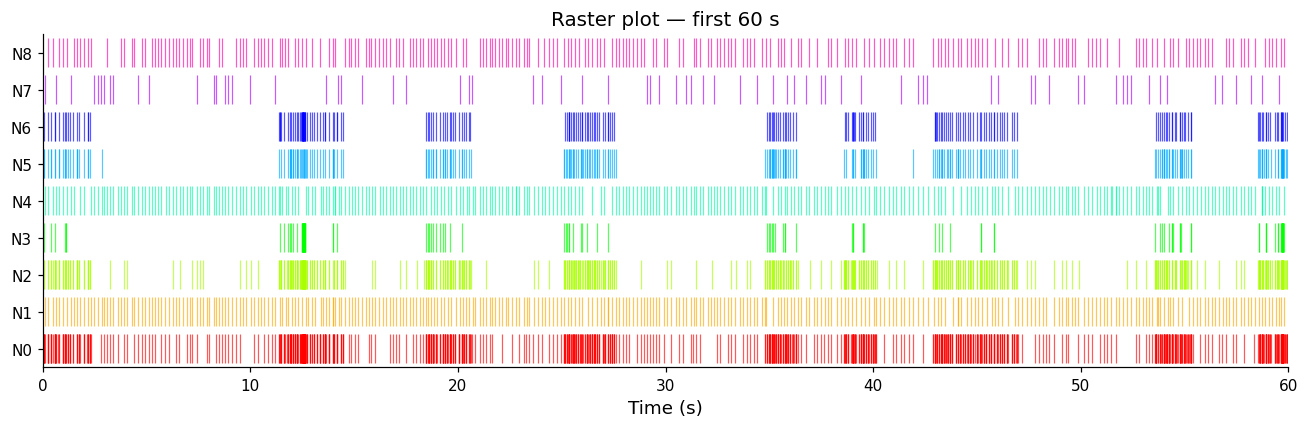

In [2]:
# Run this cell to plot the raster plots

def plot_raster(spike_trains, labels, colors, T, t_start=0, t_end=None, title="Raster plot"):
    """Plot a raster for a list of spike trains.

    Parameters
    ----------
    spike_trains : list of np.ndarray  — spike times in seconds, one per neuron
    labels       : list of str         — neuron labels (one per row)
    colors       : list of str         — tick colour per neuron
    T            : float               — total recording duration (s)
    t_start/end  : float               — time window to display
    """

    t_end = t_end or T
    fig, ax = plt.subplots(figsize=(12, 4))

    for i, (st, lbl, col) in enumerate(zip(spike_trains, labels, colors)):
        mask = (st >= t_start) & (st <= t_end)
        spikes_in_window = st[mask]

        ax.vlines(spikes_in_window, i + 0.1, i + 0.9, color=col, linewidth=0.8, alpha = 0.65)

    ax.set_yticks(np.arange(len(labels)) + 0.5)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_title(title)
    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0, len(labels))
    plt.tight_layout()
    plt.show()


# Show the first 60 seconds of the recording in a raster plot
plot_raster(spike_trains, neuron_labels, COLORS, T,
            t_end=60, title="Raster plot — first 60 s")

> **Inspect the raster.** Can you identify neurons that appear to fire regularly, irregularly,
> or in bursts without doing any calculations yet? What visual cues do you use?
>
> Try changing `t_end` to `30` or `120` for a closer or broader view. What do you see?

---
### 1.2 · Spike-Time Triggered Raster Plot (STTRP)

Spike-time triggered raster plots (STTRPs) show how all neurons respond in the short time window *after* each spike of a designated trigger neuron.

**How it works:**

1. For every spike of the trigger neuron, open a 10 ms window.
2. Collect all spikes from all neurons that fall within that window, relative to the trigger spike.
3. Plot each collected spike as a dot: x = latency after the trigger (ms), y = time of the trigger spike (minutes).

Each neuron is shown in a distinct colour. The result is a time-resolved picture of how pairwise
and population-level interactions evolve over the course of the recording.

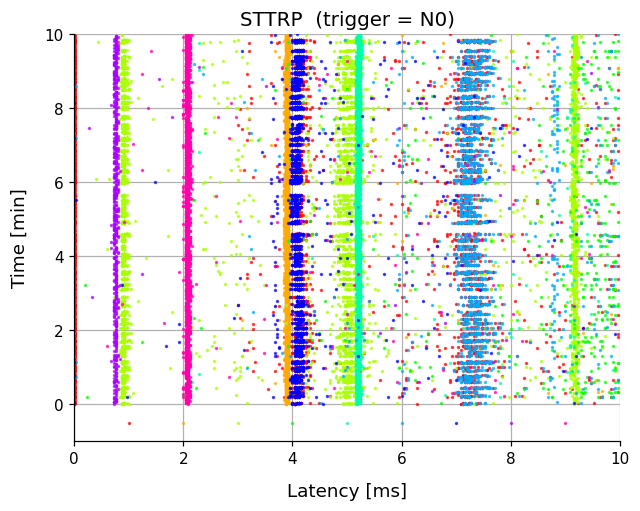

In [3]:
# Run this cell to plot the Spike-time triggered raster plots
def plot_sttrps(elecs, trigger):
    """Spike-Train Time-Resolved Plot (STTRP).

    Parameters
    ----------
    elecs   : list of np.ndarray  — spike times in *milliseconds*, one per neuron
    trigger : int                 — index of the trigger neuron
    """
    
    tot_elements = len(elecs)
    no_before    = 10   # minimum gap before a trigger spike in ms
    stth_length  = 10   # window length after the trigger spike in ms

    plt.figure()

    latencies = [[] for _ in range(tot_elements)]
    times     = [[] for _ in range(tot_elements)]

    i = 0
    while i < elecs[trigger].shape[0]:
        if i == 0 or elecs[trigger][i] - elecs[trigger][i - 1] > no_before:
            time_start = elecs[trigger][i]
            time_stop  = time_start + stth_length

            for j in range(tot_elements):
                timepoints = elecs[j]
                if len(timepoints) == 0:
                    continue
                timepoints = timepoints[
                    np.logical_and(timepoints >= time_start, timepoints < time_stop)
                ] - time_start
                for timepoint in timepoints:
                    times[j].append(timepoint)
                    latencies[j].append(time_start / (1000 * 60))
        i += 1

    for i in range(tot_elements):
        time    = np.array(times[i])
        latency = np.array(latencies[i])

        if time.shape[0] > 1:
            time[0]    = 1 + i
            latency[0] = -0.5

        plt.plot(time, latency, '.',
                 color=np.array(colorsys.hsv_to_rgb(i / tot_elements, 1, 1)),
                 markersize=2.5, alpha=0.65)

    plt.xlim([0, stth_length])
    plt.ylim([-1, 10])
    plt.xlabel("Latency [ms]", fontsize=12, labelpad=10)
    plt.ylabel("Time [min]", fontsize=12, labelpad=10)
    plt.grid(True)
    plt.title(f"STTRP  (trigger = N{trigger})")
    plt.show()

elecs_ms = [st * 1000 for st in spike_trains]

TRIGGER = 0   # CHANGE THIS TO PLOT A DIFFERENT NEURON AS TRIGGER
plot_sttrps(elecs_ms, TRIGGER)

> **Set `TRIGGER`** to the index of any neuron you are interested in and re-run the cell.
> Try neurons with different firing patterns and compare the plots.

---
## Section 2 · Mean Firing Rate

The mean firing rate is the simplest quantitative summary of neural activity. It describes the average number of spikes per second, measured in Hz:

$$r = \frac{N_{\text{spikes}}}{T}$$

The activity of neurons is not stationary and changes over time. For this kind of data it is useful to compute the time-varying firing rate by counting the spikes in a sliding window:

$$r(t) = \frac{n_{\text{spikes in } [t,\; t+\Delta t]}}{\Delta t}$$

### Your tasks
1. Compute the mean firing rate for each neuron.
2. Compute and plot the time-varying firing rate for each neuron using 500 ms bins.


### Task 2.1 — Mean firing rate

Compute the mean firing rate (Hz) for each neuron. Store results in `firing_rates`.


In [4]:
firing_rates = []

for st in spike_trains:
    rate = len(st)/T
    firing_rates.append(rate)

print(f"  {'Neuron':<22}  {'Mean rate (Hz)':>15}")
print("  " + "-" * 40)
for lbl, r in zip(neuron_labels, firing_rates):
    print(f"  {lbl:<22}  {r:>15.2f}")

  Neuron                   Mean rate (Hz)
  ----------------------------------------
  N0                                13.80
  N1                                 5.90
  N2                                 8.53
  N3                                 1.32
  N4                                 5.85
  N5                                 3.77
  N6                                 3.40
  N7                                 1.44
  N8                                 4.24


### Task 2.2 — Time-varying firing rate

Complete `compute_firing_rate()` by filling in the two missing lines.


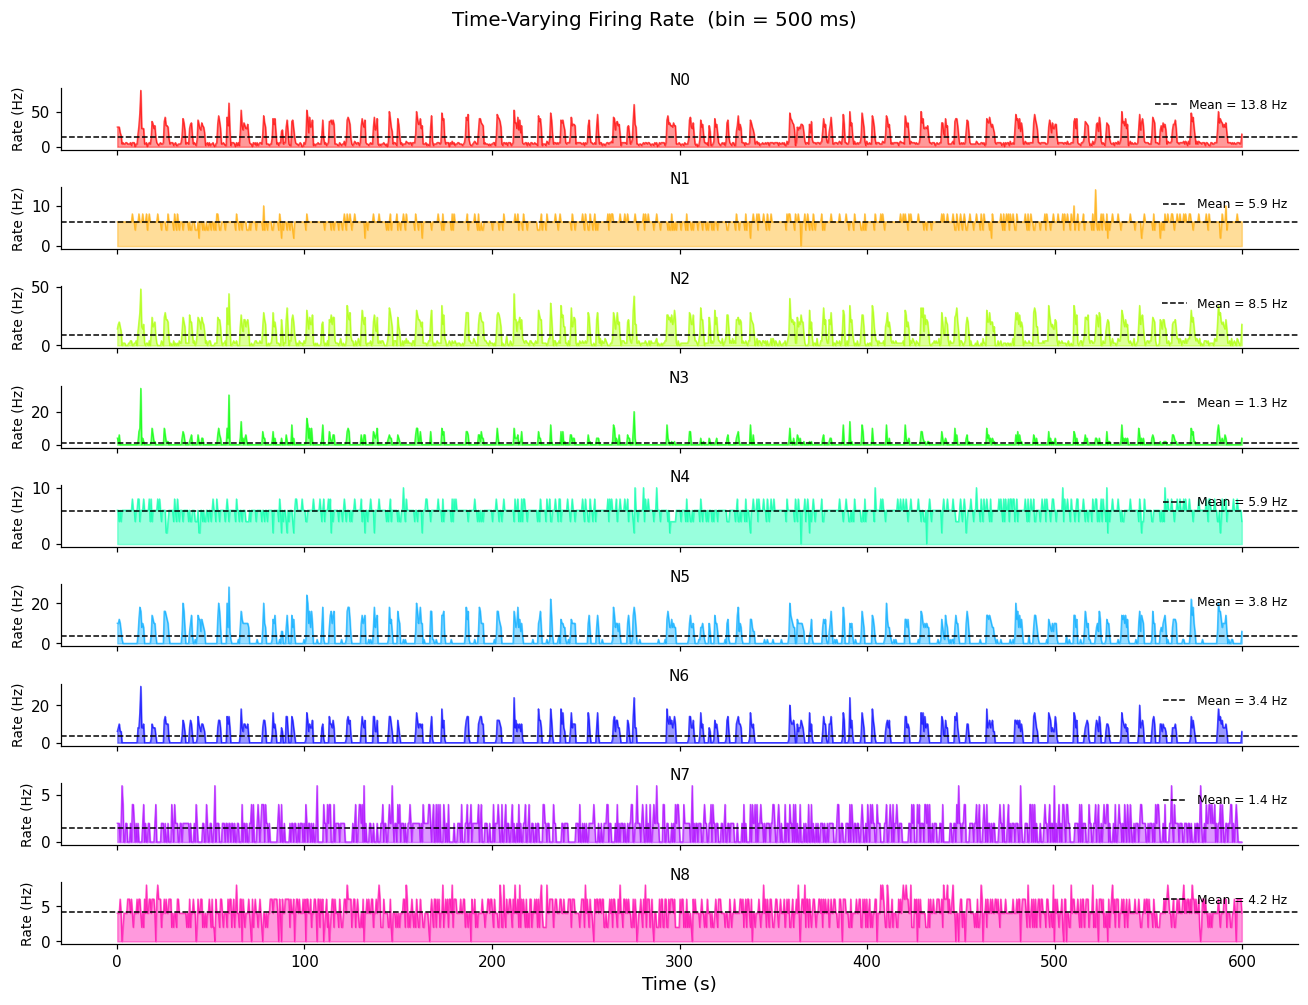

In [5]:
def compute_firing_rate(spike_train, T, bin_size=0.5):

    """Compute time-varying firing rate in non-overlapping bins for a single spike train.

    Returns
    -------
    t_centres : np.ndarray  — bin centre times (s)
    rate      : np.ndarray  — firing rate in each bin (Hz)
    """

    edges = np.arange(0, T + bin_size, bin_size)
    t_centres = 0.5 * (edges[:-1] + edges[1:])

    counts, _ = np.histogram(spike_train, bins=edges)
    rate = counts/bin_size # TODO: convert counts to firing rate in Hz

    return t_centres, rate


# PLOTTING FUNCTION
fig, axes = plt.subplots(len(spike_trains), 1, figsize=(12, 9), sharex=True)
for ax, st, lbl, col, r_mean in zip(axes, spike_trains, neuron_labels, COLORS, firing_rates):
    t_centres, rate = compute_firing_rate(st, T, bin_size=0.5)
    ax.fill_between(t_centres, rate, alpha=0.4, color=col)
    ax.plot(t_centres, rate, color=col, linewidth=0.9, alpha=0.65)
    ax.axhline(r_mean, color="black", linewidth=1, linestyle="--",
               label=f"Mean = {r_mean:.1f} Hz")
    ax.set_ylabel("Rate (Hz)", fontsize=9)
    ax.set_title(lbl, fontsize=10, pad=2)
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Time-Varying Firing Rate  (bin = 500 ms)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

> **Observation:** Notice the difference in firing rate trace between neurons with bursty firing patters and more regularly-firing neurons.

---
## Section 3 · ISI Distribution & Coefficient of Variation

The inter-spike interval (ISI) is the time between two consecutive spikes of a single neuron:

$$\text{ISI}_i = t_{i+1} - t_i$$

The shape of the ISI distribution is a fingerprint of the neuron's firing pattern:


| Distribution shape | Interpretation |
|--------------------|----------------|
| Narrow, unimodal | Regular (tonic) firing — nearly constant intervals |
| Exponential | Poisson-like — random, memory-less spiking |
| Bimodal | Bursty — short ISIs *within* bursts, long ISIs *between* bursts |

### Coefficient of Variation (CV)

The CV compresses the entire distribution into a single number that quantifies firing regularity:

$$\text{CV} = \frac{\sigma_{\text{ISI}}}{\mu_{\text{ISI}}}$$

| CV | Interpretation |
|----|----------------|
| $\ll 1$ | More regular than Poisson (e.g. pacemaker-like neurons) |
| $\approx 1$ | Poisson-like (exponential ISI distribution) |
| $> 1$ | More irregular than Poisson — often a sign of burst firing |

### Task 3.1 — Compute ISIs and plot their distributions

For each neuron, compute the ISIs using `np.diff(spike_train)` and plot a histogram.
Use **logarithmic bins** — ISIs span several orders of magnitude and a linear x-axis compresses
the short-ISI range where the most interesting structure lies.

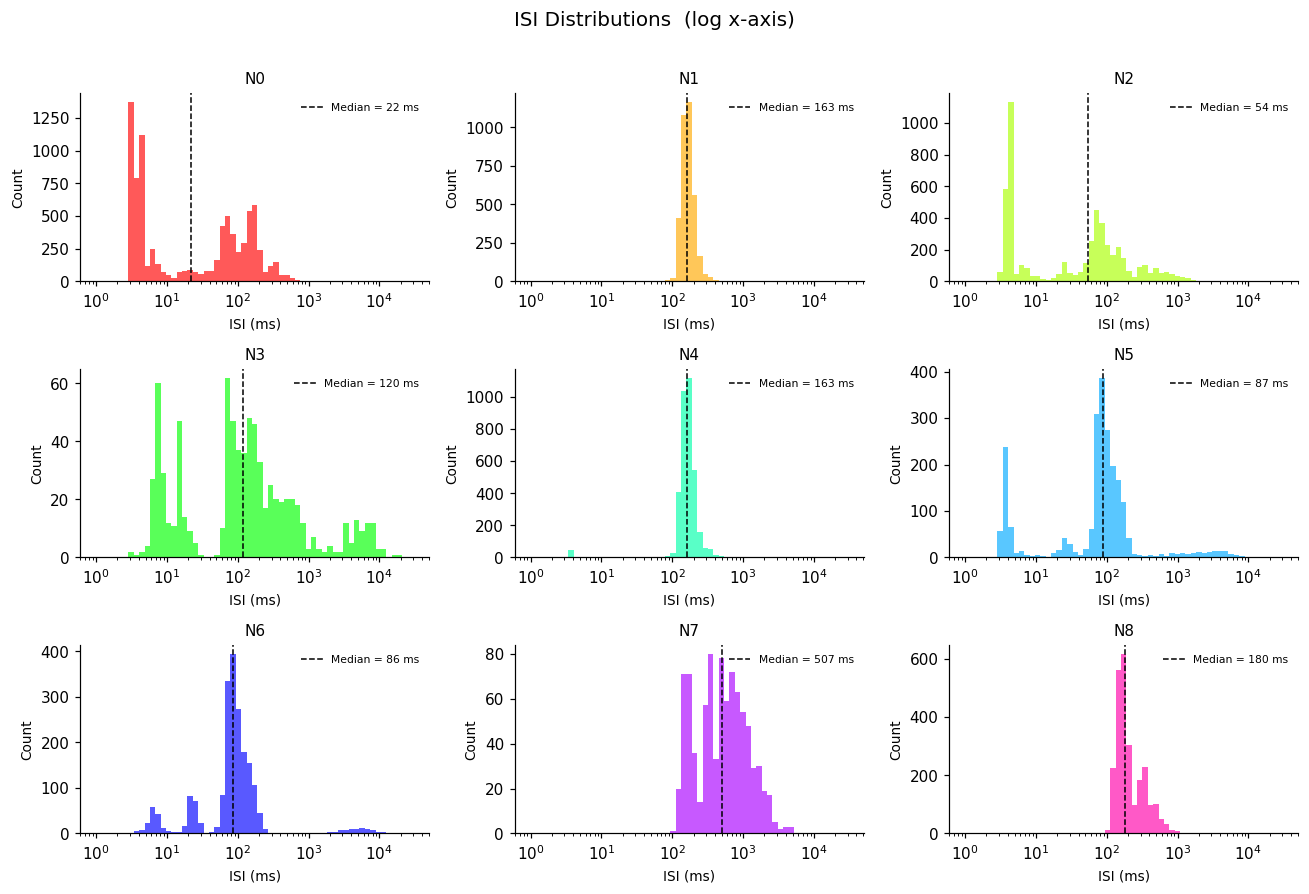

In [6]:
bins = np.logspace(0, np.log10(30_000), 60) # Logarithmically spaced bins

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, st, lbl, col in zip(axes, spike_trains, neuron_labels, COLORS):
    
    isis = np.diff(st) # TODO: compute the inter-spike intervals (ISIs) in seconds for this spike train using np.diff()
    isis_ms = isis*1000 # TODO: convert ISIs to milliseconds

    # PLOTTING, no need to change anything below
    ax.hist(isis_ms, bins=bins, color=col, alpha=0.65, edgecolor="none")
    ax.set_xscale("log")
    ax.axvline(np.median(isis_ms), color="black", linestyle="--", linewidth=1,
               label=f"Median = {np.median(isis_ms):.0f} ms")
    ax.set_xlabel("ISI (ms)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle("ISI Distributions  (log x-axis)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Task 3.2 — Compute the CV of the ISI

Compute the CV for each neuron, print a summary table, and produce a bar chart.
The dashed reference line at CV = 1 marks the expectation for a Poisson process.

  Neuron                   Mean ISI (ms)   SD ISI (ms)        CV
  --------------------------------------------------------------
  N0                                72.5         100.7     1.390
  N1                               169.4          44.9     0.265
  N2                               117.2         231.0     1.971
  N3                               760.2        1993.8     2.623
  N4                               170.9          53.6     0.313
  N5                               265.1         848.0     3.199
  N6                               294.4        1196.3     4.064
  N7                               690.6         630.9     0.913
  N8                               236.1         133.4     0.565


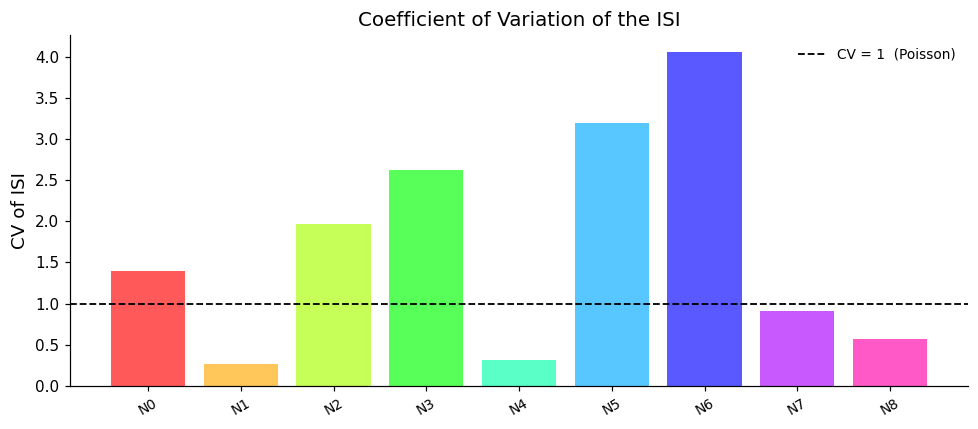

In [7]:
cvs        = []
mean_isis  = []
std_isis   = []

for st in spike_trains:
    isis_ms = np.diff(st) * 1000   # ms
    mean_isis.append(np.mean(isis_ms)) # TODO: compute the mean ISI in ms for this spike train
    std_isis.append(np.std(isis_ms)) # TODO: compute the standard deviation of the ISI in ms for this spike train``
    cvs.append(np.std(isis_ms)/np.mean(isis_ms)) # TODO: compute the CV of the ISI for this spike train

# Summary table (provided, no need to change anything here)
print(f"  {'Neuron':<22}  {'Mean ISI (ms)':>14}  {'SD ISI (ms)':>12}  {'CV':>8}")
print("  " + "-" * 62)
for lbl, mu, sd, cv in zip(neuron_labels, mean_isis, std_isis, cvs):
    print(f"  {lbl:<22}  {mu:>14.1f}  {sd:>12.1f}  {cv:>8.3f}")

# Bar plot (provided, no need to change anything here)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(neuron_labels)), cvs, color=COLORS, alpha=0.65)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2,
           label="CV = 1  (Poisson)")
ax.set_xticks(range(len(neuron_labels)))
ax.set_xticklabels(neuron_labels, rotation=30, fontsize=9)
ax.set_ylabel("CV of ISI")
ax.set_title("Coefficient of Variation of the ISI")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Questions to consider:**
- Which neurons have CV > 1? Do they match the neurons that appeared bursty in the raster?
- Can you see a bimodal ISI distribution for any neuron? What do the two peaks represent?
- A perfectly regular neuron would have CV = 0. What would its ISI distribution look like?
- Compare the CV values with the mean firing rates from Section 2. Is there a relationship between rate and regularity, or are they independent?

> **Connection to Section 4:** The ISI distribution is useful for choosing the burst-detection
> threshold $\theta$. A good $\theta$ sits in the **trough** between the short-ISI
> (intra-burst) and long-ISI (inter-burst) peaks of a bimodal distribution.

---
## Section 4 · Burst Detection & Burst Metrics

Bursts are episodes of unusually high-frequency spiking within a single neuron's spike train. The most widely used burst detection algorithm is simple and interpretable:

1. Compute all inter-spike intervals (ISIs): $\text{ISI}_i = t_{i+1} - t_i$
2. Choose a threshold $\theta$ (e.g. 100 ms): any two consecutive spikes with $\text{ISI} < \theta$ belong to the same burst
3. Require a minimum number of spikes per burst (e.g. ≥ 3)

### Burst metrics

Once bursts are identified, you can compute:

| Metric | Definition |
|--------|-----------|
| Burst rate | Number of bursts per minute |
| Burst duration | Time from first to last spike in the burst |
| Spikes per burst | Spike count inside the burst |
| Intra-burst firing rate | Mean rate *within* a burst (spikes / duration) |
| Inter-burst interval (IBI) | Time between the *start* of consecutive bursts |

### Task 4.1 — Implement `detect_bursts()`

Complete the three marked gaps inside the loop:
- When a spike **belongs** to the current burst (ISI < threshold), add it to `current_burst`.
- When a burst **ends** (ISI ≥ threshold), save it if it meets the minimum size, then start a new burst.
- After the loop, **don't forget** to save the last burst.

In [8]:
def detect_bursts(spike_train, isi_threshold=0.1, min_spikes=3):
    """Detect bursts using the ISI-threshold method.

    Parameters
    ----------
    spike_train   : np.ndarray  — spike times in seconds
    isi_threshold : float       — maximum ISI *within* a burst (seconds)
    min_spikes    : int         — minimum spikes to qualify as a burst

    Returns
    -------
    bursts : list of np.ndarray  — each element contains the spike times of one burst
    """
    
    if len(spike_train) < min_spikes:
        return []

    isis = np.diff(spike_train)
    bursts = []
    current_burst = [spike_train[0]]

    for i, isi in enumerate(isis):
        if isi < isi_threshold:
            current_burst.append(isi) # TODO: add the next spike to the current burst
        else:
            if len(current_burst) >= min_spikes:
                bursts.append(current_burst) # TODO: add the current burst to the list of bursts if the number of spikes in the burst is >= min_spikes
            current_burst = [spike_train[i + 1]] # start a new burst with the next spike

    if len(current_burst) >= min_spikes:
        bursts.append(np.array(current_burst)) # add the last burst if it qualifies

    return bursts


# Compute the summary metrics (provided, no need to change anything here)
def burst_metrics(bursts, T):
    """Return a dict of burst statistics."""
    if not bursts:
        return dict(n_bursts=0, burst_rate_bpm=0.0,
                    mean_duration_ms=float("nan"),
                    mean_spikes_per_burst=float("nan"),
                    mean_intra_rate_hz=float("nan"),
                    mean_ibi_s=float("nan"))
    durations  = np.array([b[-1] - b[0] for b in bursts])
    n_spikes   = np.array([len(b)       for b in bursts])
    intra_rate = np.where(durations > 0, n_spikes / durations, np.nan)
    starts     = np.array([b[0] for b in bursts])
    ibis       = np.diff(starts) if len(bursts) > 1 else np.array([np.nan])
    return dict(
        n_bursts             = len(bursts),
        burst_rate_bpm       = len(bursts) / T * 60,
        mean_duration_ms     = np.nanmean(durations) * 1000,
        mean_spikes_per_burst= np.nanmean(n_spikes),
        mean_intra_rate_hz   = np.nanmean(intra_rate),
        mean_ibi_s           = np.nanmean(ibis),
    )

### Task 4.2 — Set per-neuron ISI thresholds and run burst detection

Go back to the ISI histograms in Section 3. For each neuron that shows a **bimodal distribution**, identify the trough between the short-ISI (intra-burst) peak and the long-ISI (inter-burst) peak — that trough value is your threshold.

For neurons without a clear bimodal structure, you can simply set the threshold to 0.


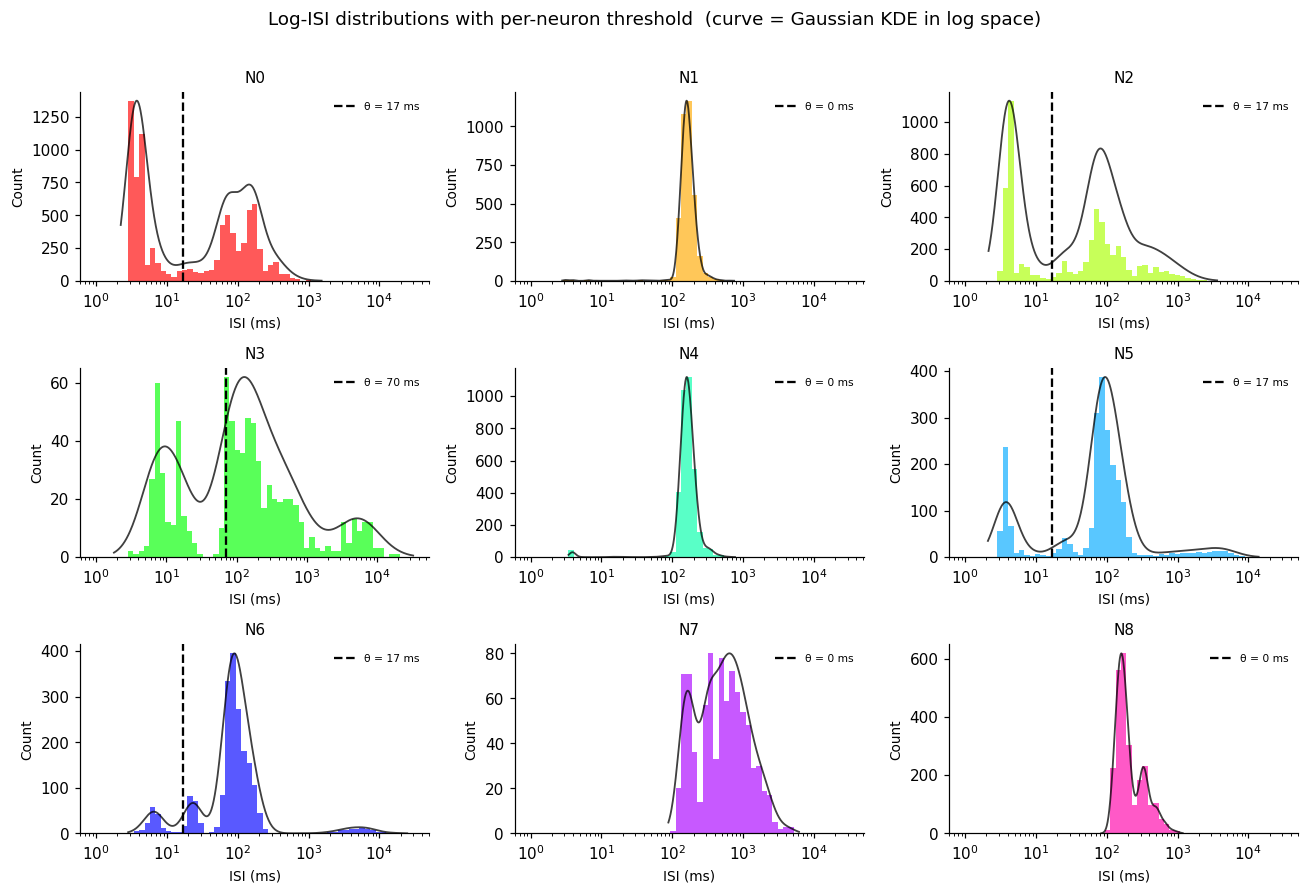

In [10]:
# Run this cell with the provided threshold values first, then experiment with different values to see how they affect burst detection

MIN_SPIKES = 3

thresholds_ms = {
    "N0": 17,
    "N1": 0,
    "N2": 17,
    "N3": 70,
    "N4": 0,
    "N5": 17,
    "N6": 17,
    "N7": 0,
    "N8": 0,
}

# thresholds_ms = {
#     "N0": 100,
#     "N1": 0,
#     "N2": 250,
#     "N3": 2000,
#     "N4": 0,
#     "N5": 400,
#     "N6": 500,
#     "N7": 0,
#     "N8": 0,
# }


bins = np.logspace(0, np.log10(30_000), 60)

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, st, lbl, col in zip(axes, spike_trains, neuron_labels, COLORS):
    isis_ms = np.diff(st) * 1000

    counts, _ = np.histogram(isis_ms, bins=bins)
    ax.hist(isis_ms, bins=bins, color=col, alpha=0.65, edgecolor="none")
    ax.set_xscale("log")

    # ── Overlay the Gaussian KDE used by find_isi_threshold ───────────────────
    log_isis = np.log10(isis_ms)
    n  = len(log_isis)
    bw = 1.06 * np.std(log_isis) * n ** (-0.2)
    x_log = np.linspace(log_isis.min() - bw, log_isis.max() + bw, 500)
    z   = (x_log[np.newaxis, :] - log_isis[:, np.newaxis]) / bw
    kde = np.exp(-0.5 * z ** 2).mean(axis=0)
    if kde.max() > 0:
        # Scale KDE peak to histogram peak for visual comparison
        ax.plot(10 ** x_log, kde / kde.max() * counts.max(),
                color="black", linewidth=1.2, alpha=0.75)

    # ── Threshold line ─────────────────────────────────────────────────────────
    thr = thresholds_ms[lbl]
    if thr is not None:
        ax.axvline(thr, color="black", linestyle="--", linewidth=1.5,
                   label=f"θ = {thr:.0f} ms")
        ax.legend(fontsize=7)

    ax.set_xlabel("ISI (ms)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_title(lbl, fontsize=10)

plt.suptitle("Log-ISI distributions with per-neuron threshold  "
             "(curve = Gaussian KDE in log space)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# ── Run burst detection ────────────────────────────────────────────────────────
all_bursts  = []
all_metrics = []

for lbl, st in zip(neuron_labels, spike_trains):
    bursts  = detect_bursts(st, thresholds_ms[lbl] / 1000, MIN_SPIKES)
    metrics = burst_metrics(bursts, T)
    all_bursts.append(bursts)
    all_metrics.append(metrics)

print(f"  {'Neuron':<8}  {'θ (ms)':>8}  {'Bursts':>7}  {'bpm':>6}  "
      f"{'Dur(ms)':>8}  {'Spk/bst':>8}  {'IntraHz':>8}  {'IBI(s)':>7}")
print("  " + "-" * 72)
for lbl, thr, m in zip(neuron_labels, thresholds_ms.values(), all_metrics):
    print(f"  {lbl:<8}  {thr:>8.0f}  {m['n_bursts']:>7}  {m['burst_rate_bpm']:>6.1f}  "
          f"{m['mean_duration_ms']:>8.1f}  {m['mean_spikes_per_burst']:>8.1f}  "
          f"{m['mean_intra_rate_hz']:>8.1f}  {m['mean_ibi_s']:>7.1f}")

  Neuron      θ (ms)   Bursts     bpm   Dur(ms)   Spk/bst   IntraHz   IBI(s)
  ------------------------------------------------------------------------
  N0              17     1541   154.1  -298379.1       3.4       nan      0.4
  N1               0        0     0.0       nan       nan       nan      nan
  N2              17      179    17.9  -296003.4       3.5       nan      3.4
  N3              70       47     4.7  -242614.6       3.9       nan     12.8
  N4               0        0     0.0       nan       nan       nan      nan
  N5              17       22     2.2  -143623.6       3.3       nan     23.6
  N6              17       17     1.7  -276112.4       3.6       nan     35.9
  N7               0        0     0.0       nan       nan       nan      nan
  N8               0        0     0.0       nan       nan       nan      nan


/tmp/ipykernel_717486/596617421.py:55: RuntimeWarning: Mean of empty slice
  mean_intra_rate_hz   = np.nanmean(intra_rate),


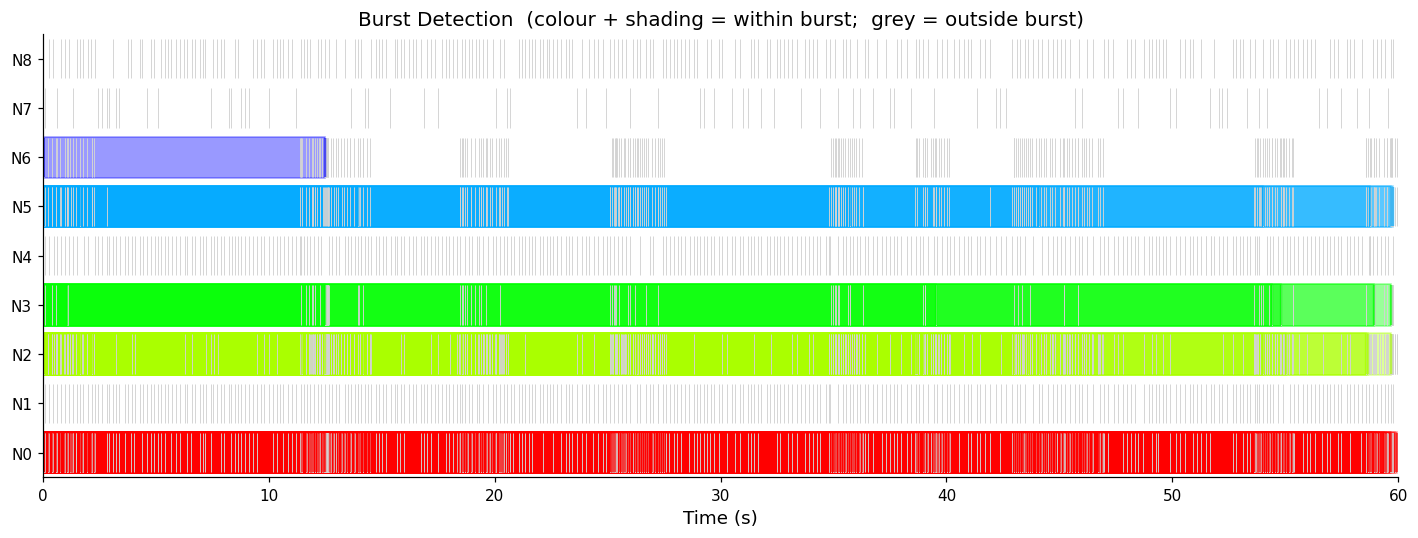

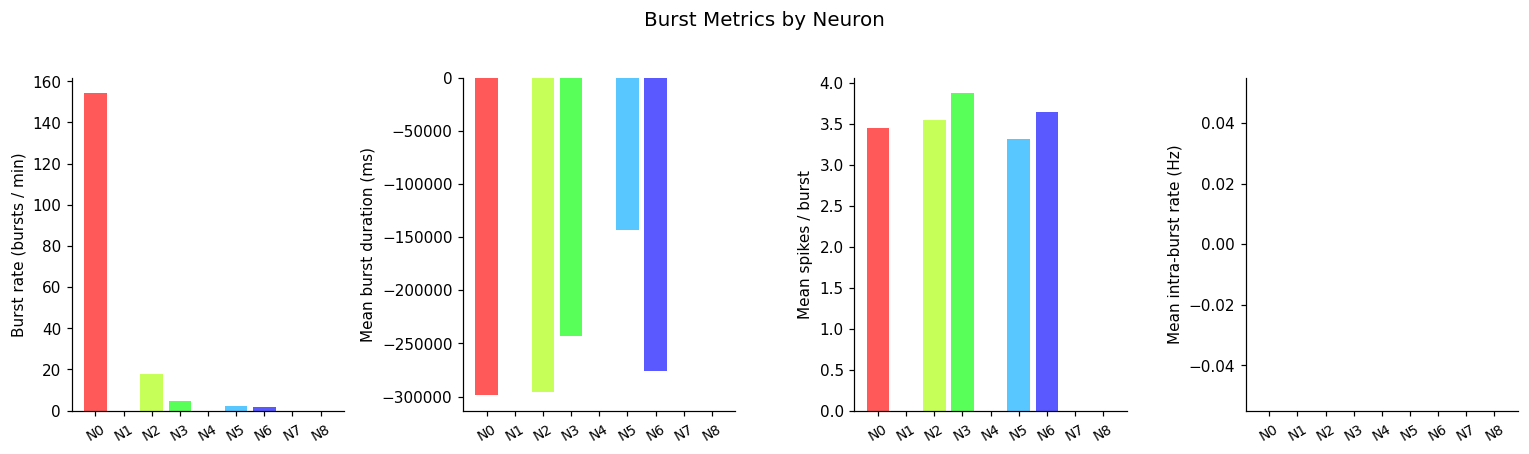

In [12]:
# THIS IS A PLOTTING CELL, NO NEED TO CHANGE ANYTHING BELOW UNLESS YOU WANT TO CUSTOMISE THE PLOT APPEARANCE
def plot_burst_detection(spike_trains, all_bursts, labels, colors,
                         T, t_start=0, t_end=60):
    fig, ax = plt.subplots(figsize=(13, 5))

    for i, (st, bursts, lbl, col) in enumerate(zip(spike_trains, all_bursts, labels, colors)):
        mask = (st >= t_start) & (st <= t_end)
        # All spikes in light grey
        ax.vlines(st[mask], i + 0.1, i + 0.9, color="lightgray", linewidth=0.6)
        # Burst spikes in colour with shaded background
        for burst in bursts:
            if burst[0] > t_end or burst[-1] < t_start:
                continue
            ax.vlines(burst, i + 0.1, i + 0.9, color=col, linewidth=1.6, alpha=0.65)
            ax.axhspan(i + 0.08, i + 0.92,
                       xmin=(max(burst[0], t_start) - t_start) / (t_end - t_start),
                       xmax=(min(burst[-1], t_end)  - t_start) / (t_end - t_start),
                       alpha=0.4, color=col)

    ax.set_yticks(np.arange(len(labels)) + 0.5)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_title("Burst Detection  (colour + shading = within burst;  grey = outside burst)")
    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0, len(labels))
    plt.tight_layout()
    plt.show()


# Burst metrics bar charts (provided, no need to change anything here unless you want to customise the plot appearance)
def plot_burst_metrics(all_metrics, labels, colors):
    keys = [
        ("burst_rate_bpm",        "Burst rate (bursts / min)"),
        ("mean_duration_ms",      "Mean burst duration (ms)"),
        ("mean_spikes_per_burst", "Mean spikes / burst"),
        ("mean_intra_rate_hz",    "Mean intra-burst rate (Hz)"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (key, ylabel) in zip(axes, keys):
        vals = [m[key] if not np.isnan(m.get(key, np.nan)) else 0 for m in all_metrics]
        ax.bar(range(len(labels)), vals, color=colors, alpha=0.65)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels([l.split()[0] for l in labels], rotation=30, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
    plt.suptitle("Burst Metrics by Neuron", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_burst_detection(spike_trains, all_bursts, neuron_labels, COLORS, T, t_end=60)
plot_burst_metrics(all_metrics, neuron_labels, COLORS)

**Questions to consider:**
- Did the algorithm find bursts in the neurons that appeared regular in the raster? Should it have?
- Pick a neuron that clearly bursts and compare its **intra-burst firing rate** with its **mean firing rate**. What does this tell you about how a bursty neuron "spends" its spikes?
- **Parameter sensitivity:** Change `ISI_THRESHOLD` to be in the second trough of the ISI distribution. How do the burst metrics change? What does this tell you about the reliability of this method?

---
## Section 6 · Pairwise Pearson Correlation & the Effect of Bin Size

### What is the Pearson correlation?

The Pearson correlation coefficient $r$ measures the **linear relationship** between two variables $X$ and $Y$:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \, \sigma_Y} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2} \cdot \sqrt{\sum_i (y_i - \bar{y})^2}}$$

It is bounded between −1 and +1 regardless of the units of $X$ and $Y$:

| $r$ | Meaning |
|-----|---------|
| +1 | Perfect positive linear relationship — when one goes up, so does the other |
| 0 | No linear relationship — knowing $X$ tells you nothing about $Y$ |
| −1 | Perfect negative linear relationship — when one goes up, the other goes down |

The coefficient only captures *linear* associations. Two variables can be strongly related in a nonlinear sense and still produce $r \approx 0$.

---

### Applying it to spike trains

To measure how synchronously two neurons fire, you convert each spike train into a **time series of spike counts** by dividing the recording into bins of width $\Delta t$ and counting spikes in each bin. Then you compute the Pearson $r$ between the two count vectors:

$$r_{AB} = \frac{\text{Cov}(n_A,\, n_B)}{\sigma_A \, \sigma_B}$$

where $n_A[k]$ and $n_B[k]$ are the spike counts of neurons A and B in bin $k$.

A high $r$ means the two neurons tend to fire *at the same times*; a low $r$ means their activity is unrelated. Computing $r$ for every pair and arranging the results as a matrix gives a **correlation matrix** — a compact summary of the synchrony structure across the whole population.


The bin size $\Delta t$ determines at which timescale we are measuring the correlation. Larger bins generally give higher correlations because more spikes end up in the same bin.

### Task 6.1 — Implement `pairwise_correlation_matrix()`

Fill in the two missing lines:
1. Convert the spike times of each neuron into a binned count vector using `np.histogram`.
2. Compute the Pearson $r$ between every pair using `np.corrcoef` and extract the off-diagonal element `[0, 1]`.

In [ ]:
def pairwise_correlation_matrix(spike_trains, T, bin_size=0.05):
    """Compute the pairwise Pearson correlation matrix.

    Parameters
    ----------
    spike_trains : list of np.ndarray  — spike times in seconds
    T            : float               — recording duration (s)
    bin_size     : float               — bin width (s)

    Returns
    -------
    corr_matrix : np.ndarray, shape (N, N)
    """
    
    N     = len(spike_trains)
    edges = np.arange(0, T + bin_size, bin_size)

    binned = np.zeros((N, len(edges) - 1))
    for k, st in enumerate(spike_trains):
        binned[k], _ = # TODO: bin the spike train using np.histogram to get spike counts in each bin

    corr_matrix = np.eye(N)
    for i in range(N):
        for j in range(i + 1, N):
            r = # TODO: compute the Pearson correlation coefficient between the binned spike counts of neuron i and neuron j using np.corrcoef(). Extract the off-diagonal element [0, 1] which contains the correlation between the two neurons.
            corr_matrix[i, j] = r
            corr_matrix[j, i] = r

    return corr_matrix


# ── Compute with a 50 ms bin as a first look ─────────────────────────────────
corr_50ms = pairwise_correlation_matrix(spike_trains, T, bin_size=0.05)

short = [l.split()[0] for l in neuron_labels]
print("Correlation matrix  (bin = 50 ms):")
print("         " + "  ".join(f"{s:>6}" for s in short))
for i, row in enumerate(corr_50ms):
    print(f"  {short[i]:>4}   " + "  ".join(f"{v:>6.3f}" for v in row))

### Task 6.2 — Explore the effect of bin size

The cell below computes correlation matrices at four different bin sizes and plots them side by side.
**You do not need to write any code here**. Just run the cell and study the result.

In [ ]:
# ── PROVIDED: side-by-side correlation matrices at four bin sizes ─────────────
bin_sizes   = [0.005, 0.05, 0.2, 1.0]
bin_labels  = ["5 ms", "50 ms", "200 ms", "1 s"]
short_names = [l.split()[0] for l in neuron_labels]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

for ax, bs, bl in zip(axes, bin_sizes, bin_labels):
    cm = pairwise_correlation_matrix(spike_trains, T, bin_size=bs)
    im = ax.imshow(cm, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Pearson r")
    ax.set_xticks(range(len(neuron_labels)))
    ax.set_yticks(range(len(neuron_labels)))
    ax.set_xticklabels(short_names, rotation=35, fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_title(f"Bin = {bl}", fontsize=11)
    for i in range(len(neuron_labels)):
        for j in range(len(neuron_labels)):
            v = cm[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(v) > 0.6 else "black")

plt.suptitle("Pairwise Spike-Train Correlations — Effect of Bin Size", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# ── Also show how a single pair's correlation changes with bin size ────────────
# Pick three pairs of interest — feel free to change the indices after
# inspecting the raster and burst results above.
bin_range  = np.logspace(np.log10(0.002), np.log10(2.0), 40)
pair_labels = [("N5", "N6", 5, 6),
               ("N4", "N5", 4, 5),
               ("N0", "N4", 0, 4)]

fig, ax = plt.subplots(figsize=(8, 4.5))
for lbl_a, lbl_b, i, j in pair_labels:
    rs = []
    for bs in bin_range:
        cm = pairwise_correlation_matrix(spike_trains, T, bin_size=bs)
        rs.append(cm[i, j])
    ax.semilogx(bin_range * 1000, rs, linewidth=2, label=f"{lbl_a} vs {lbl_b}")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Bin size (ms)")
ax.set_ylabel("Pearson r")
ax.set_title("Pairwise Correlation vs. Bin Size")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Questions to consider:**
- Look at the 4-panel matrix plot. Which pairs have the highest correlation at 5 ms? Does the ranking change at 1 s?
- Find the most correlated pair in the matrix. Do they appear to fire together in the raster? Are they both bursty, both regular, or mixed?
- For a pair of neurons that both appeared bursty, does correlation *increase or decrease* with larger bins? Why?
- In the line plot, notice that for some pairs the correlation peaks at a particular bin size and then levels off. What might cause this shape?

> **Take-home message:** There is no single "correct" bin size. The choice should be driven by the
> timescale of the interaction you are interested in. Short bins capture precise coincidences;
> long bins capture slow co-modulation. A best practice is to report correlations across a range
> of bin sizes, as shown here.

---
### Critical limitations of Pearson correlation

Pearson correlation is a useful first-pass measure of co-activity, but it comes with important caveats that are easy to overlook.

**1. Correlation does not imply a direct connection**

A high $r_{AB}$ means neurons A and B tend to fire at the same times, nothing more. Three very different mechanisms can produce the same result:

| Scenario | What you see | What it does not mean |
|----------|-------------|----------------------|
| A → B (direct excitatory synapse) | A and B fire together | — |
| A ← C → B (shared input from C) | A and B fire together | A drives B |
| A and B both driven by a slow network state | A and B fire together | any direct link |

**2. The network burst problem**

In this dataset, the bursty group (N0, N2, N5, N6, …) all participate in the same network bursts. This alone drives their pairwise correlations toward 1 at large bin sizes — regardless of whether they are connected to each other. The measured $r$ is largely a readout of *whether two neurons participate in the same network events*, not of their specific connectivity.

**3. The linear-only assumption**

Pearson $r$ only captures linear relationships. Two neurons could have a strong but nonlinear interaction (e.g., A only drives B above a certain rate threshold) and still produce $r \approx 0$.

**4. Non-stationarity**

The method assumes that the firing statistics of each neuron are stable across the recording. If neurons change their firing rate or pattern over time (e.g. due to adaptation, drift, or changing network states), the single correlation value mixes together different epochs and may be misleading.

> **Bottom line:** Pearson correlation is a good tool for detecting *co-activity* at a chosen timescale. Interpreting a high correlation as evidence of a synaptic connection requires additional methods.